# Task 2 — Multi-Modal Cardiac Image Fusion (CT + MRI)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "data"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CT_PATH = os.path.join(DATA_DIR, "ct_slice.png")
MRI_PATH = os.path.join(DATA_DIR, "mri_slice.png")


## 1. Load Modalities

CT  shape: (256, 256) | mean: 6.05 std: 17.21
MRI shape: (256, 256) | mean: 26.34 std: 36.89


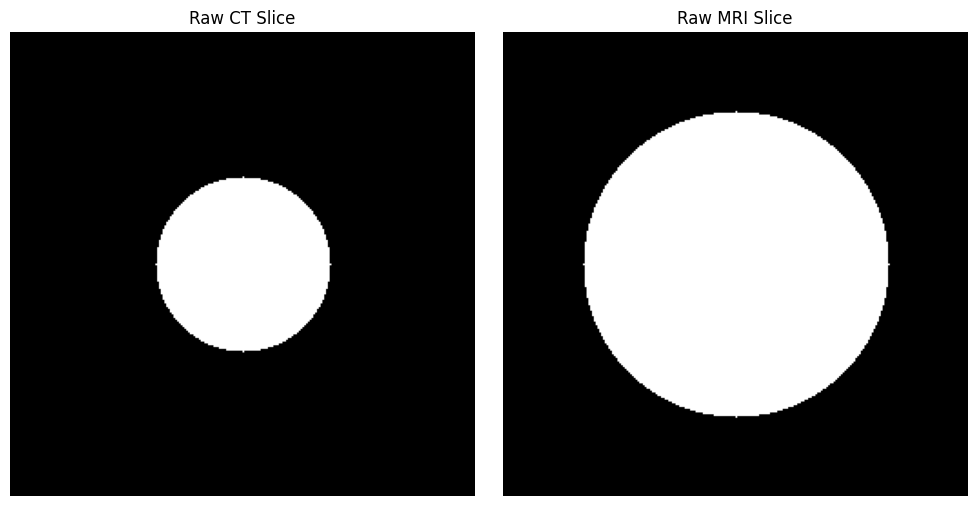

In [2]:
ct = cv2.imread(CT_PATH, cv2.IMREAD_GRAYSCALE)
mri = cv2.imread(MRI_PATH, cv2.IMREAD_GRAYSCALE)

assert ct is not None, f"Could not load CT slice at {CT_PATH}"
assert mri is not None, f"Could not load MRI slice at {MRI_PATH}"

# Ensure both matrices share identical dimensions before any pixel-wise math
if ct.shape != mri.shape:
    mri = cv2.resize(mri, (ct.shape[1], ct.shape[0]))

print("CT  shape:", ct.shape,  "| mean: %.2f std: %.2f" % (ct.mean(), ct.std()))
print("MRI shape:", mri.shape, "| mean: %.2f std: %.2f" % (mri.mean(), mri.std()))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ct, cmap="gray"); axes[0].set_title("Raw CT Slice"); axes[0].axis("off")
axes[1].imshow(mri, cmap="gray"); axes[1].set_title("Raw MRI Slice"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_raw_ct_mri.png"), dpi=150)
plt.show()


## 2. Histogram Equalization (independent, per modality)

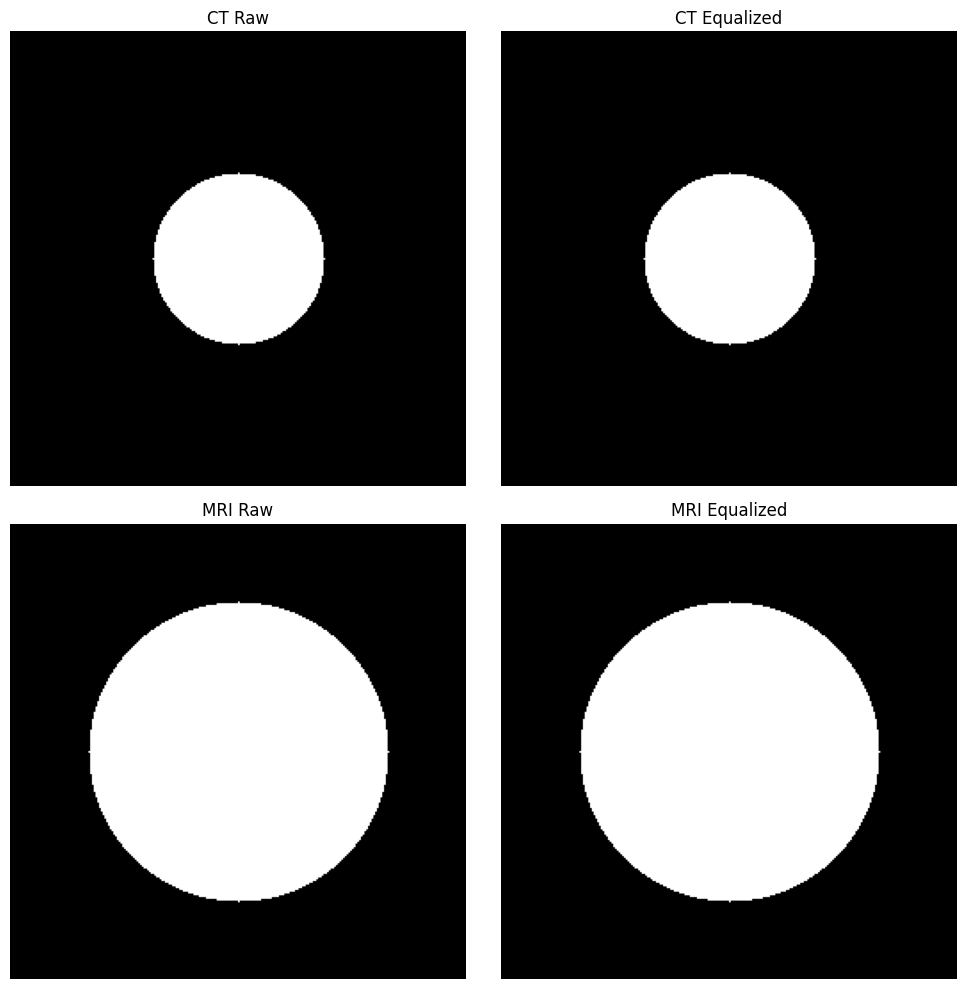

True

In [3]:
ct_eq = cv2.equalizeHist(ct)
mri_eq = cv2.equalizeHist(mri)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(ct, cmap="gray"); axes[0, 0].set_title("CT Raw"); axes[0, 0].axis("off")
axes[0, 1].imshow(ct_eq, cmap="gray"); axes[0, 1].set_title("CT Equalized"); axes[0, 1].axis("off")
axes[1, 0].imshow(mri, cmap="gray"); axes[1, 0].set_title("MRI Raw"); axes[1, 0].axis("off")
axes[1, 1].imshow(mri_eq, cmap="gray"); axes[1, 1].set_title("MRI Equalized"); axes[1, 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_equalized_ct_mri.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "02_ct_equalized.png"), ct_eq)
cv2.imwrite(os.path.join(OUTPUT_DIR, "02_mri_equalized.png"), mri_eq)


**Documentation:** Equalizing each modality *independently* is important — CT and MRI have
fundamentally different intensity distributions (CT values relate to radiodensity, MRI
values relate to proton relaxation), so a single shared equalization curve would distort one
modality relative to the other. Independent equalization maximizes each modality's own
dynamic range before they are combined.


## 3. Color Mapping and Naive Overlay

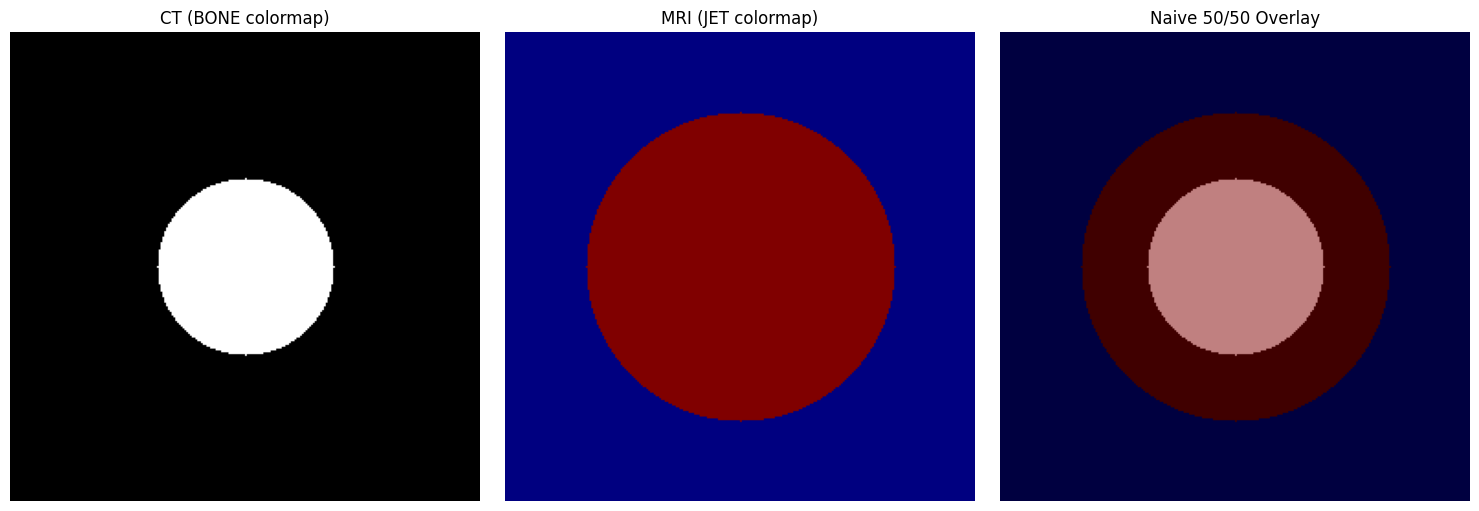

True

In [4]:
ct_heat = cv2.applyColorMap(ct_eq, cv2.COLORMAP_BONE)   # CT -> bone colormap (structural)
mri_heat = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)  # MRI -> jet colormap (soft-tissue)

naive_overlay = cv2.addWeighted(ct_heat, 0.5, mri_heat, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(ct_heat, cv2.COLOR_BGR2RGB)); axes[0].set_title("CT (BONE colormap)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(mri_heat, cv2.COLOR_BGR2RGB)); axes[1].set_title("MRI (JET colormap)"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(naive_overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("Naive 50/50 Overlay"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_colormap_overlay.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "03_ct_heatmap.png"), ct_heat)
cv2.imwrite(os.path.join(OUTPUT_DIR, "03_mri_heatmap.png"), mri_heat)


## 4. Multi-Modal Weighted Fusion — `cv2.addWeighted`

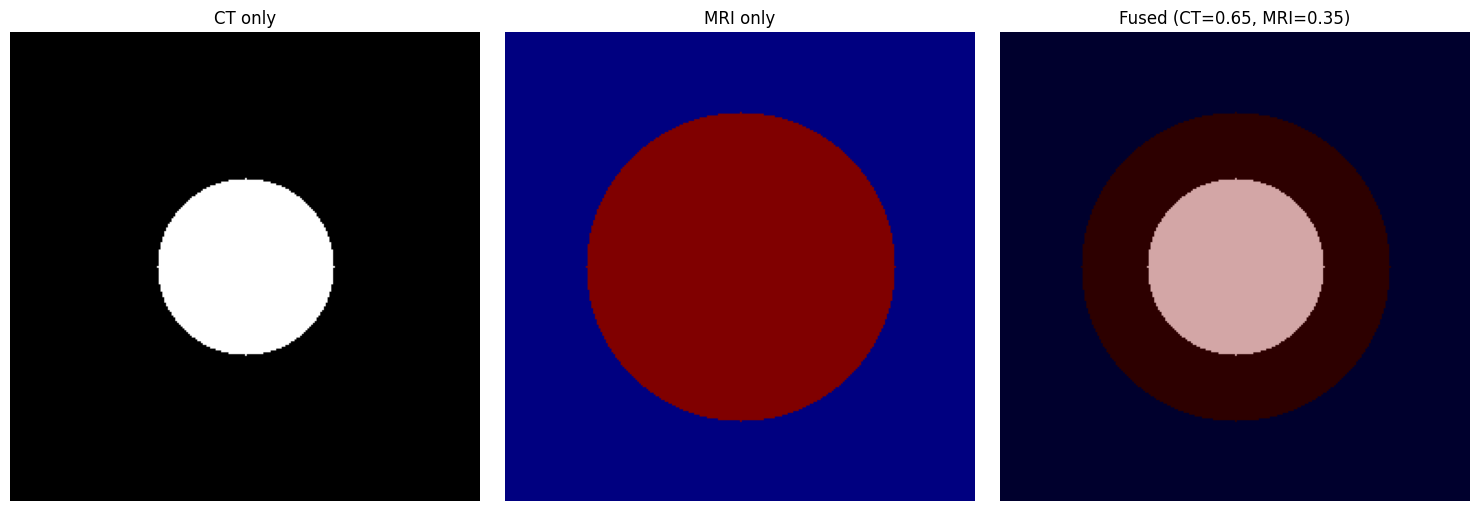

True

In [5]:
# Weighting logic:
#   alpha (CT) heavier  -> preserves sharp anatomical/bone edges
#   beta  (MRI) lighter -> contributes internal soft-tissue variation without washing out edges
ALPHA_CT = 0.65
BETA_MRI = 0.35
GAMMA_OFFSET = 0

fused = cv2.addWeighted(ct_heat, ALPHA_CT, mri_heat, BETA_MRI, GAMMA_OFFSET)

show_titles = [
    ("CT only", ct_heat),
    ("MRI only", mri_heat),
    (f"Fused (CT={ALPHA_CT}, MRI={BETA_MRI})", fused),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, show_titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_weighted_fusion.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "04_fused_output.png"), fused)


**Fusion weighting logic:** `cv2.addWeighted` computes
`dst = alpha*src1 + beta*src2 + gamma`. Assigning `alpha=0.65` to the CT channel keeps its
crisp chamber/bone boundaries dominant in the final image, while `beta=0.35` on the MRI
channel is just enough to blend in soft-tissue texture cues without over-saturating or
"washing out" those sharp CT edges. This ratio was chosen empirically — try adjusting
`ALPHA_CT` / `BETA_MRI` above and re-running to see the trade-off between edge sharpness and
tissue-texture visibility.


## 5. Logarithmic and Power-Law Correction of the Fused Matrix

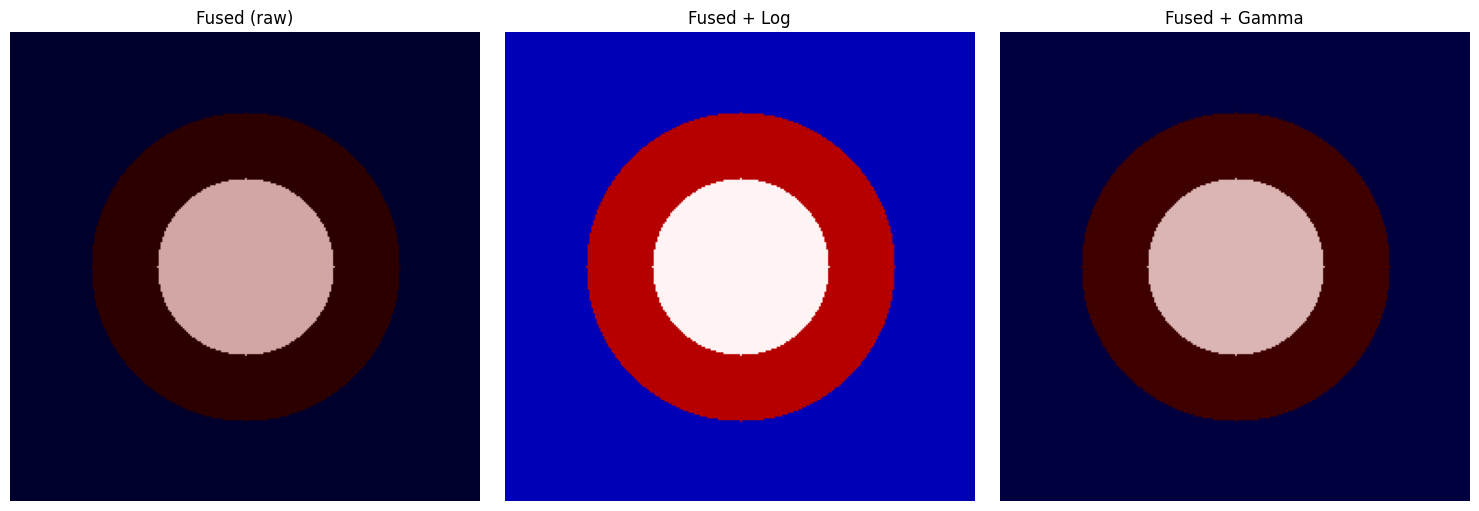

raw fused        -> crushed(0):  0.00%   blown(255):  0.00%
log-corrected    -> crushed(0):  0.00%   blown(255):  0.00%
gamma-corrected  -> crushed(0):  0.00%   blown(255):  0.00%


In [6]:
def log_transform(img, c=None):
    img_f = img.astype(np.float32)
    if c is None:
        c = 255 / np.log(1 + img_f.max())
    return np.clip(c * np.log(1 + img_f), 0, 255).astype(np.uint8)

def gamma_transform(img, gamma=0.8, c=1.0):
    img_norm = img.astype(np.float32) / 255.0
    return np.clip(c * np.power(img_norm, gamma) * 255, 0, 255).astype(np.uint8)

fused_log = log_transform(fused)
fused_gamma = gamma_transform(fused, gamma=0.8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(fused, cv2.COLOR_BGR2RGB)); axes[0].set_title("Fused (raw)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(fused_log, cv2.COLOR_BGR2RGB)); axes[1].set_title("Fused + Log"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB)); axes[2].set_title("Fused + Gamma"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_log_gamma_correction.png"), dpi=150)
plt.show()

cv2.imwrite(os.path.join(OUTPUT_DIR, "05_fused_log.png"), fused_log)
cv2.imwrite(os.path.join(OUTPUT_DIR, "05_fused_gamma.png"), fused_gamma)

# Quantify clipping: fraction of pixels crushed to 0 or blown to 255
for name, img in [("raw fused", fused), ("log-corrected", fused_log), ("gamma-corrected", fused_gamma)]:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    crushed = (gray == 0).mean() * 100
    blown = (gray == 255).mean() * 100
    print(f"{name:16s} -> crushed(0): {crushed:5.2f}%   blown(255): {blown:5.2f}%")


**Documentation:** Additive blending of two already-bright heatmaps risks pushing many
pixels to pure white (255) or, after subsequent operations, crushing shadow detail to pure
black (0) — both are a loss of diagnostic information. The log transform expands the
low-intensity tail (recovers shadow detail) while the gamma (`gamma<1`) transform lifts
midtones without amplifying already-saturated highlights. The clipping percentages printed
above should be lower after correction than in the raw fused image.


## 6. Comparative Analysis — CT vs MRI vs Fused, Side-by-Side

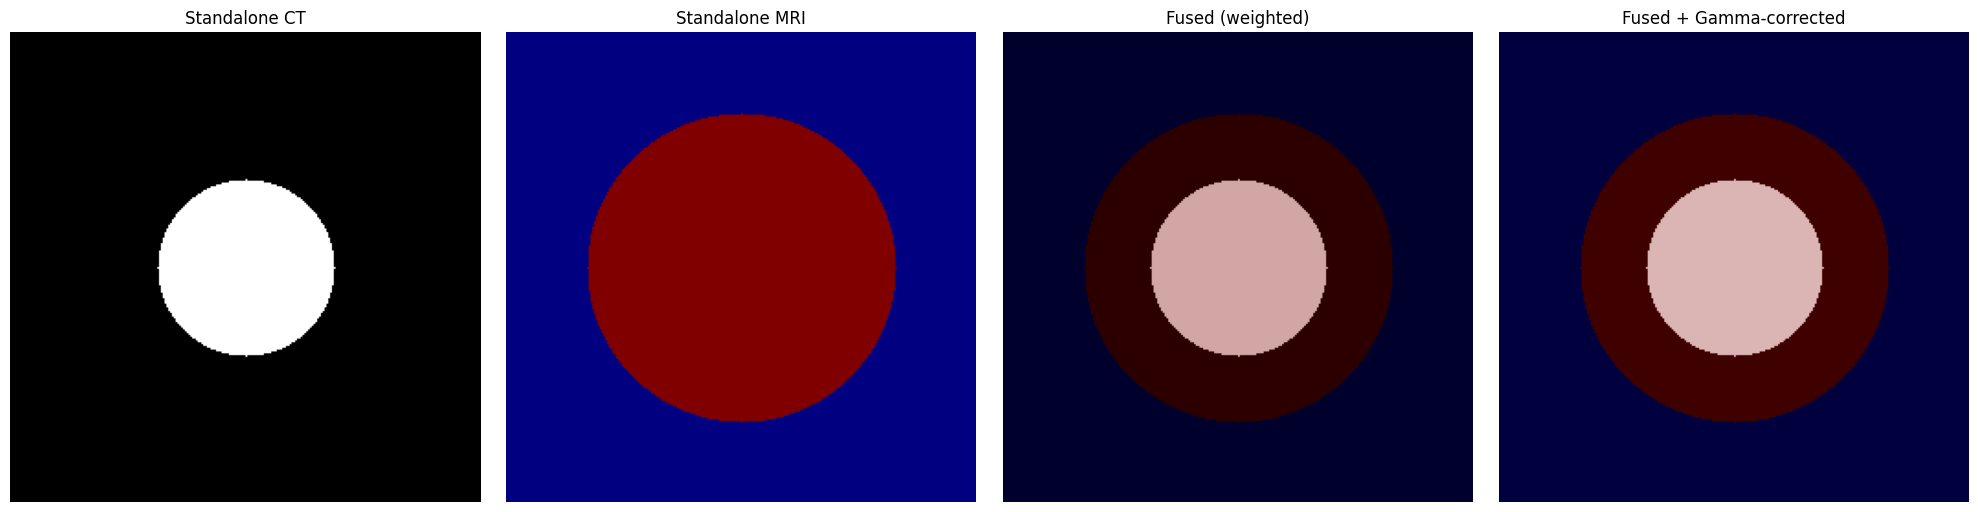

Fusion pipeline complete. All stages saved to: output


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
panels = [
    ("Standalone CT", cv2.cvtColor(ct_heat, cv2.COLOR_BGR2RGB)),
    ("Standalone MRI", cv2.cvtColor(mri_heat, cv2.COLOR_BGR2RGB)),
    ("Fused (weighted)", cv2.cvtColor(fused, cv2.COLOR_BGR2RGB)),
    ("Fused + Gamma-corrected", cv2.cvtColor(fused_gamma, cv2.COLOR_BGR2RGB)),
]
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_comparative_analysis.png"), dpi=150)
plt.show()

print("Fusion pipeline complete. All stages saved to:", OUTPUT_DIR)
